<h1> Sharukh Khan (sk2765)</h1>

## Midterm project: Equity Portfolio Management

### Data Preparation

Download the historial daily data of the entire 2018 for the 10 stocks 

```python
universe = ['IBM', 'MSFT', 'GOOG', 'AAPL', 'AMZN', 'FB', 'NFLX', 'TSLA', 'ORCL', 'SAP']
```

For example, to download IBM data, use the following link to go to yahoo finance page. Find the "Download Data" link to download the csv file to you local disk.
https://finance.yahoo.com/quote/IBM/history?period1=1514782800&period2=1546232400&interval=1d&filter=history&frequency=1d

Replace "IBM" with other stock symbol in the above URL, you will be able to download data for other 9 stocks.

You should have 10 csv files on your disk now. IBM.csv, MSFT.csv, etc. We call the 10 stocks "universe" which is the entire stock market you can trade.



### Retrieve the "Close" and "Adj Close" values for each stock

You will create a dataframe where there are 20 columns for the 10 stocks, each row is the "Close" and "Adj Close" prices for the 10 stocks on each day, in the order of the business days in 2018. Assume all buy/sell on the "Close" prices and there is no transaction cost.

### You start to manage 5 million dollars fund on Jan 02, 2018

You have a strategy to manage the fund.

1. On Jan 02 2018, you split the \\$5m into 5 \\$1m, and use them to buy 5 stocks from the 10 stocks. For example, IBM close price was \\$154.25. With \\$1m, you can buy max 6482 shares with cost \\$999848.5 with \\$151.5‬ cash left. You decided to spend \\$1m on each of ['IBM', 'MSFT', 'GOOG', 'AAPL', 'AMZN'] respectively and keep the rest cash into a zero-interest cash account. On Jan 02 2018, your mark to market value (MTM) is \\$5m if combining all stocks value and cash. Your holdings of stocks and cach account is your portfolio.

\begin{equation*}
\ MTM^t =  cash^t + \sum_{k=1}^5 Shares_k^t \times ClosePrice_k^t \
\end{equation*}


2. Your trading strategy is "5 days rebalancing of buying low". Here is how it works. You keep your portfolio unchanged until 5 days later on Jan 09 2018. Now you want to re-check the market and adjust your portfolio. You will compute the "Adj Close" price changes from Jan 02 to Jan 09, and find the 5 stocks whose "Adj Close" prices dropped the most in terms of percentage. You sell all current holdings on Jan 09 "Close" prices to convert your portfolio to all cash. Then immediately split your cash, including your cash account, to 5 equal parts to buy the 5 stocks that dropped the most from Jan 02 to Jan 09 on 'Adj Close' prices. You always buy the max shares of stock on the "Close" price and keep the rest cash in cash account. Now the portfolio should be different from 5 days ago. This operation is called "rebalancing".

    Keep in mind, the MTM will change every day, even when your portfolio holdings don't change, because the stock prices change.


3. Corporations generally issue stock dividends on some days. The total dividend you get on such a day is the stock dividend  times your shares if you have shares of this stock on the dividend day. If you buy shares on the dividend day, these bought shares are not qualified to get dividend. If you sell shares on the dividend day, the sold shares are qualified to get dividend. For example, on 2/8/2018, IBM issued \$1.5 dividend per share. In your cash account, you will automatically get

\begin{equation*}
\$1.5 \times \left(your\ IBM\ shares\ on\ 2/8/2018\right)
\end{equation*} 



4. 5 business days later on Jan 17 (Jan 15 was a holiday), you re-check the market and adjust your portfolio again. You will have a new portfolio on Jan 17.


5. If you run this strategy every 5 days all the way to Dec 31 2018, you will have a daily MTM. You expect the MTM on Dec 31 2018 should be higher than \$5m because you always buy the stocks that dropped the most, i.e., you always buy low.


6. Another strategy is "5 days rebalancing of buying high". You always buy the 5 stocks whose "Adj Close" prices surge the most in terms of percentage because you believe the trend will continue. Run the new strategy and see how the MTM will change.


7. You will create a "high tech index" which is simply the daily average of the 10 stocks "Close" prices. Compare your MTM series with the "high tech index" and plot their curves. To plot the two curves together, you may want to convert the series to daily percentage change with regard to Jan 02 2018.


8. Download the USD/JPY 2018 historical data at https://www.myfxbook.com/en/forex-market/currencies/USDJPY-historical-data then use the "Close" column as the rate to convert your MTM series from USD to JPY. Plot the two MTM curves. You will need to convert to daily percentage change too.


9. The above two strategies both rebalance every 5 days. Try to change the days interval and find the optimal days interval that maximizes the MTM on 12/31/2018. 

### Submit

* This project must be in R.

* This is a group project. Your group can have up to 4 members. 

* Submit your jupyter notebook file in both HTML format and ipynb format with all intermediate results and the final dataframe. Plot the curves. Each member will need to submit a copy on canvas.

* Due in 3 week from today.





<h1>Loading all csv files and setting up dataframes</h1>

In [2]:
require(data.table)
library(dplyr)
library(lubridate)
library(tidyr)
library(ggplot2)
library(grid)
library(gridExtra)
library(gtable)
library(plotly)
library(purrr)

In [3]:
ibmData=read.csv("IBM.csv")
msftData=read.csv("MSFT.csv")
googData=read.csv("GOOG.csv")
aaplData=read.csv("AAPL.csv")
amznData=read.csv("AMZN.csv")
fbData=read.csv("META.csv")
nflxData=read.csv("NFLX.csv")
tslaData=read.csv("TSLA.csv")
orclData=read.csv("ORCL.csv")
sapData=read.csv("SAP.csv")

In [4]:
IBM = ibmData[,c("Date","Close","Adj.Close")]
MSFT = msftData[,c("Close","Adj.Close")]
GOOG = googData[, c("Close","Adj.Close")]
AAPL = aaplData[, c("Close","Adj.Close")]
AMZN = amznData[, c("Close","Adj.Close")]
FB = fbData[, c("Close","Adj.Close")]
NFLX = nflxData[, c("Close","Adj.Close")]
TSLA = tslaData[, c("Close","Adj.Close")]
ORCL = orclData[, c("Close","Adj.Close")]
SAP = sapData[, c("Close","Adj.Close")]

In [5]:
universe = data.frame(IBM$Date, IBM$Close, IBM$Adj.Close,
                        MSFT$Close, MSFT$Adj.Close,
                        GOOG$Close, GOOG$Adj.Close,
                        AAPL$Close, AAPL$Adj.Close,
                        AMZN$Close, AMZN$Adj.Close,
                        FB$Close,   FB$Adj.Close,
                        NFLX$Close, NFLX$Adj.Close,
                        TSLA$Close, TSLA$Adj.Close,
                        ORCL$Close, ORCL$Adj.Close,
                        SAP$Close,  SAP$Adj.Close)
colnames(universe) = c("Date", "ibm_close", "ibm_adj_close",
                        "msft_close", "msft_adj_close",
                        "goog_close", "goog_adj_close",
                        "aapl_close", "aapl_adj_close",
                        "amzn_close", "amzn_adj_close",
                        "fb_close",   "fb_adj_close",
                        "nflx_close", "nflx_adj_close",
                        "tsla_close", "tsla_adj_close",
                        "orcl_close", "orcl_adj_close",
                        "sap_close", "sap_adj_close")

universe = universe %>% arrange(as.Date(Date, format = "%d-%b-%y"))

#Reverse the table
universe$Date = format(lubridate::dmy(universe$Date), "%Y-%m-%d")

head(universe)
tail(universe)

,Date,ibm_close,ibm_adj_close,msft_close,msft_adj_close,goog_close,goog_adj_close,aapl_close,aapl_adj_close,amzn_close,⋯,fb_close,fb_adj_close,nflx_close,nflx_adj_close,tsla_close,tsla_adj_close,orcl_close,orcl_adj_close,sap_close,sap_adj_close
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2018-01-02,147.47,107.53,85.95,79.79,53.25,53.12,43.06,40.57,59.45,⋯,181.42,180.88,201.07,201.07,21.37,21.37,46.63,41.87,112.39,99.96
2,2018-01-03,151.52,110.49,86.35,80.16,54.12,53.99,43.06,40.56,60.21,⋯,184.67,184.12,205.05,205.05,21.15,21.15,47.71,42.84,113.31,100.77
3,2018-01-04,154.59,112.72,87.11,80.87,54.32,54.19,43.26,40.75,60.48,⋯,184.33,183.78,205.63,205.63,20.97,20.97,48.18,43.26,115.05,102.32
4,2018-01-05,155.34,113.27,88.19,81.87,55.11,54.98,43.75,41.21,61.46,⋯,186.85,186.29,209.99,209.99,21.11,21.11,48.47,43.52,116.33,103.46
5,2018-01-08,156.28,113.96,88.28,81.96,55.35,55.21,43.59,41.06,62.34,⋯,188.28,187.71,212.05,212.05,22.43,22.43,48.98,43.98,114.80,102.10
6,2018-01-09,156.63,114.21,88.22,81.90,55.31,55.18,43.58,41.06,62.63,⋯,187.87,187.31,209.31,209.31,22.25,22.25,49.06,44.22,114.16,101.53


,Date,ibm_close,ibm_adj_close,msft_close,msft_adj_close,goog_close,goog_adj_close,aapl_close,aapl_adj_close,amzn_close,⋯,fb_close,fb_adj_close,nflx_close,nflx_adj_close,tsla_close,tsla_adj_close,orcl_close,orcl_adj_close,sap_close,sap_adj_close
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
245,2018-12-20,108.05,82.35,101.51,95.87,50.47,50.35,39.21,37.49,73.04,⋯,133.40,133.00,260.58,260.58,21.03,21.03,46.24,42.18,100.10,90.39
246,2018-12-21,106.06,80.84,98.23,92.77,48.98,48.86,37.68,36.03,68.87,⋯,124.95,124.57,246.39,246.39,21.32,21.32,44.00,40.14,96.14,86.81
247,2018-12-24,102.84,78.38,94.13,88.90,48.81,48.69,36.71,35.10,67.20,⋯,124.06,123.69,233.88,233.88,19.69,19.69,42.69,38.94,95.00,85.78
248,2018-12-26,106.49,81.16,100.56,94.97,51.97,51.85,39.29,37.57,73.54,⋯,134.18,133.78,253.67,253.67,21.74,21.74,44.59,40.68,98.38,88.84
249,2018-12-27,108.78,82.91,101.18,95.56,52.19,52.07,39.04,37.33,73.08,⋯,134.52,134.12,255.57,255.57,21.08,21.08,44.97,41.02,98.99,89.39
250,2018-12-28,108.06,82.36,100.39,94.81,51.85,51.73,39.06,37.35,73.90,⋯,133.20,132.80,256.08,256.08,22.26,22.26,44.82,40.89,99.20,89.58


<h1> Initial Portofilio</h1>

In [6]:
# Initialize Portfolio
initializePortfolio = function() {
    remainingCash <<- 0
    mtmSeries <<- c(5000000)

    # List of stocks to invest in
    stocks = c("ibm", "msft", "goog", "aapl", "amzn")
    totalShares <<- vector("list", length(stocks))  # List to store total shares for each stock

    # Buying initial portfolio stocks on 1st business day (Jan 2, 2018)
    for (stock in stocks) {
        closePrev = universe[1, paste0(stock, "_close")]
        adjClosePrev = universe[1, paste0(stock, "_adj_close")]
        
        # Initialize total shares
        totalShares[[stock]] <<- floor(1000000 / closePrev)
        assign(paste0("total", toupper(stock), "Shares"), totalShares[[stock]], envir = .GlobalEnv) #allows us to create or modify variables in the global environment
        remainingCash <<- remainingCash + (1000000 %% closePrev)
        
        assign(paste0(stock, "ClosePrev"), closePrev, envir = .GlobalEnv)
        assign(paste0(stock, "AdjClosePrev"), adjClosePrev, envir = .GlobalEnv)
        
        cat(paste0("\nTotal ", stock, " shares: "), totalShares[[stock]])
    }

    cat("\nTotal Remaining Cash: ")
    cat(remainingCash)

    # Initialize non-portfolio stocks
    nonPortfolioStocks = c("fb", "nflx", "tsla", "orcl", "sap")
    for (nonStock in nonPortfolioStocks) {
        assign(paste0(nonStock, "ClosePrev"), universe[1, paste0(nonStock, "_close")], envir = .GlobalEnv)
        assign(paste0(nonStock, "AdjClosePrev"), universe[1, paste0(nonStock, "_adj_close")], envir = .GlobalEnv)
        assign(paste0("total", toupper(nonStock), "Shares"), 0, envir = .GlobalEnv)  # Initialize shares to 0
    }
}

initializePortfolio()



Total ibm shares:  6781
Total msft shares:  11634
Total goog shares:  18779
Total aapl shares:  23223
Total amzn shares:  16820
Total Remaining Cash: 150.5

<h1>Rebalancing Function</h1>

In [7]:
#NOTE: <-- MEANS GLOBAL VARIABLE. If we dont have this our dataset gets reset and it only calculates for only Jan 2 2018
rebalance = function(dayNumber, lowStrategy, dayInterval) {
    low_strategy = lowStrategy
    dayInterval = dayInterval

    # List of stocks
    stocks = c("ibm", "msft", "goog", "aapl", "amzn", "fb", "nflx", "tsla", "orcl", "sap")
    adjCloseChanges = numeric(length(stocks))
    closeChanges = numeric(length(stocks))

    # Calculate changes for each stock
    for (i in seq_along(stocks)) {
        stock = stocks[i]
        adjClose = universe[dayNumber, paste0(stock, "_adj_close")]
        close = universe[dayNumber, paste0(stock, "_close")]
        adjClosePrev = get(paste0(stock, "AdjClosePrev"))
        closePrev = get(paste0(stock, "ClosePrev"))

        adjCloseChanges[i] = (adjClose - adjClosePrev) / adjClosePrev
        closeChanges[i] = (close - closePrev) / closePrev
    }

    currentMTM <<- 0

    #Dividend Calculation
    for (i in seq_along(stocks)) {
        stock = stocks[i]
        totalShares = get(paste0("total", toupper(stock), "Shares"))

        if (totalShares > 0) {
            adjClose = universe[dayNumber, paste0(stock, "_adj_close")]
            close = universe[dayNumber, paste0(stock, "_close")]
            adjClosePrev = get(paste0(stock, "AdjClosePrev"))
            closePrev = get(paste0(stock, "ClosePrev"))

            # Check for dividends
            if (round((adjClosePrev / adjClose), digits = 3) != round((closePrev / close), digits = 3)) {
                changeDifference = abs((adjClosePrev / adjClose) - (closePrev / close))
                dividend = changeDifference * close
                remainingCash <<- remainingCash + dividend
            }

            # Sell shares and calculate the remaining cash
            if (((dayNumber - 1) %% dayInterval) == 0) {
                remainingCash <<- remainingCash + (totalShares * close)
                assign(paste0("total", toupper(stock), "Shares"), 0, envir = .GlobalEnv)
            } else {
                currentMTM <<- currentMTM + (totalShares * close)
            }
        }
    }

    currentMTM <<- currentMTM + remainingCash
    mtmSeries <<- c(mtmSeries, currentMTM)

    # Buying the top 5 stocks
    if ((dayNumber - 1) %% dayInterval == 0) {
        budget <<- remainingCash / 5
        changesInAdjClose = adjCloseChanges

        # Determine stocks to buy based on strategy
        orderedChanges = order(changesInAdjClose)
        if (low_strategy) {
            orderedChanges = head(orderedChanges, n = 5)  # 5 most negative performing BuyingLow
        } else {
            orderedChanges = tail(orderedChanges, n = 5)  # 5 most positive performing BuyingHigh
        }

        for (j in orderedChanges) {
            stock = stocks[j]
            close = universe[dayNumber, paste0(stock, "_close")]
            boughtShares = floor(budget / close)
            sharesCost = close * boughtShares

            if (boughtShares > 0) {
                remainingCash <<- remainingCash - sharesCost
                assign(paste0("total", toupper(stock), "Shares"), get(paste0("total", toupper(stock), "Shares")) + boughtShares, envir = .GlobalEnv)
            }
        }
    }

    # Update previous closing prices for next iteration in the dataset
    for (stock in stocks) {
        assign(paste0(stock, "AdjClosePrev"), universe[dayNumber, paste0(stock, "_adj_close")], envir = .GlobalEnv)
        assign(paste0(stock, "ClosePrev"), universe[dayNumber, paste0(stock, "_close")], envir = .GlobalEnv)
    }
}


<h1>Strategy 1: Buying Low </h1>


Total ibm shares:  6781
Total msft shares:  11634
Total goog shares:  18779
Total aapl shares:  23223
Total amzn shares:  16820
Total Remaining Cash: 150.5
-----LOW STRATEGY:-----

MTM Value 5070936 


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
`geom_smooth()` using formula = 'y ~ x'


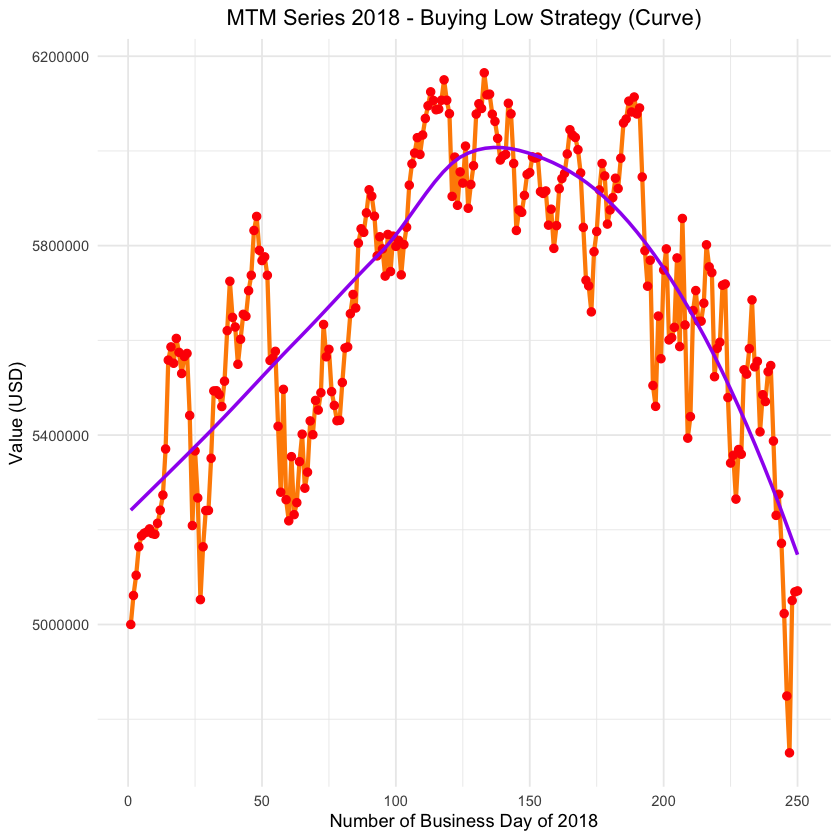

In [8]:
# Initialize the portfolio
initializePortfolio()

# Rebalancing for each business day starting from the second. Increase of 5
for (currentDay in 2:nrow(universe)) {
    rebalance(currentDay, lowStrategy = TRUE, dayInterval = 5)
}

# Display the final portfolio value after rebalancing
cat("\n-----LOW STRATEGY:-----\n\n")
cat("MTM Value", mtmSeries[length(mtmSeries)], "\n")

# Date is in the correct format. Or else the graphs will not plot
universe$Date = as.Date(universe$Date, format = "%Y-%m-%d")

# Prepare data for ggplot
mtmPlotData = data.frame(Day = 1:length(mtmSeries), MTM = mtmSeries)

# Create a plot with ggplot2
ggplot(mtmPlotData, aes(x = Day, y = MTM)) + 
    geom_line(color = "darkorange", size = 1.2) + 
    geom_point(color = "red", size = 2) +         
    geom_smooth(method = "loess", color = "purple", se = FALSE, size = 1) +  
    labs(title = "MTM Series 2018 - Buying Low Strategy (Curve)", y = "Value (USD)", x = "Number of Business Day of 2018") +
    theme_minimal() +
    theme(plot.title = element_text(hjust = 0.5))


<h1>Strategy 2: Buying High </h1>


Total ibm shares:  6781
Total msft shares:  11634
Total goog shares:  18779
Total aapl shares:  23223
Total amzn shares:  16820
Total Remaining Cash: 150.5
-----HIGH STRATEGY:-----
MTM Value 4940327 


`geom_smooth()` using formula = 'y ~ x'


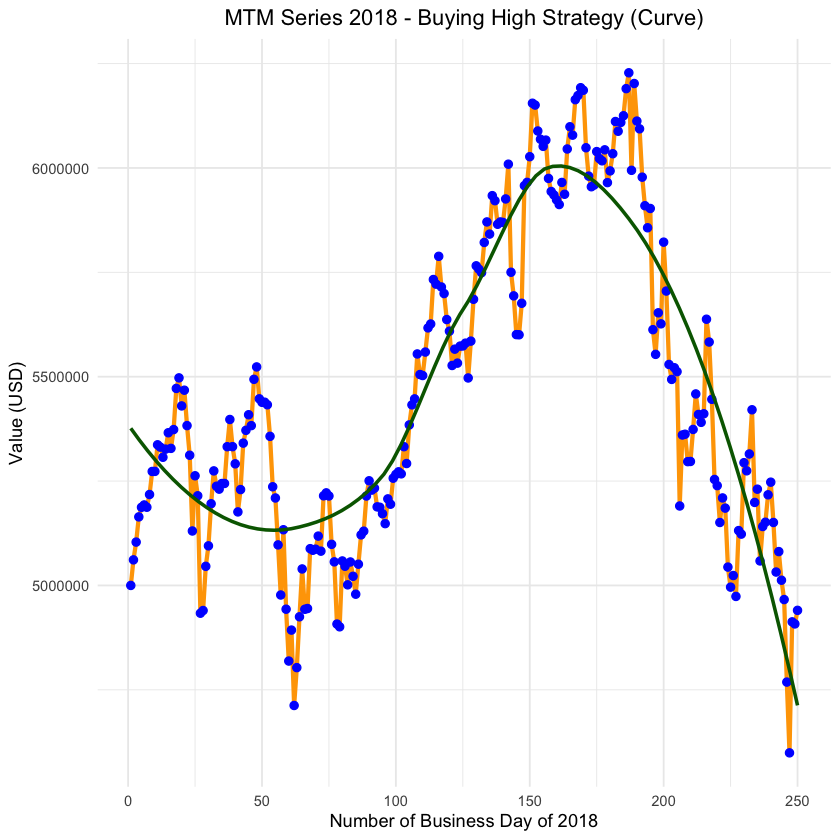

In [9]:
# Initialize Portfolio
initializePortfolio()

# Rebalancing for each business day starting from the second. Increase of 5
for (currentDay in 2:nrow(universe)) {
    rebalance(currentDay, lowStrategy = FALSE, dayInterval = 5)
}

# Display the final portfolio value after rebalancing
cat("\n-----HIGH STRATEGY:-----\n")
cat("MTM Value", mtmSeries[length(mtmSeries)], "\n")

#Date is in the correct format. Or else the graphs will not plot
universe$Date = as.Date(universe$Date, format = "%Y-%m-%d")

# Prepare data for ggplot
mtmPlotData = data.frame(Day = 1:length(mtmSeries), MTM = mtmSeries)

# Create a plot with ggplot2
ggplot(mtmPlotData, aes(x = Day, y = MTM)) + 
    geom_line(color = "orange", size = 1.2) +
    geom_point(color = "blue", size = 2) +
    geom_smooth(method = "loess", color = "darkgreen", se = FALSE, size = 1) +
    labs(title = "MTM Series 2018 - Buying High Strategy (Curve)", y = "Value (USD)", x = "Number of Business Day of 2018") +
    theme_minimal() +
    theme(plot.title = element_text(hjust = 0.5))



<h1>High Tech Index</h1>

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'
Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_line()`).”
`geom_smooth()` using method = 'loess' and formula = 'y ~ x'
Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_line()`).”


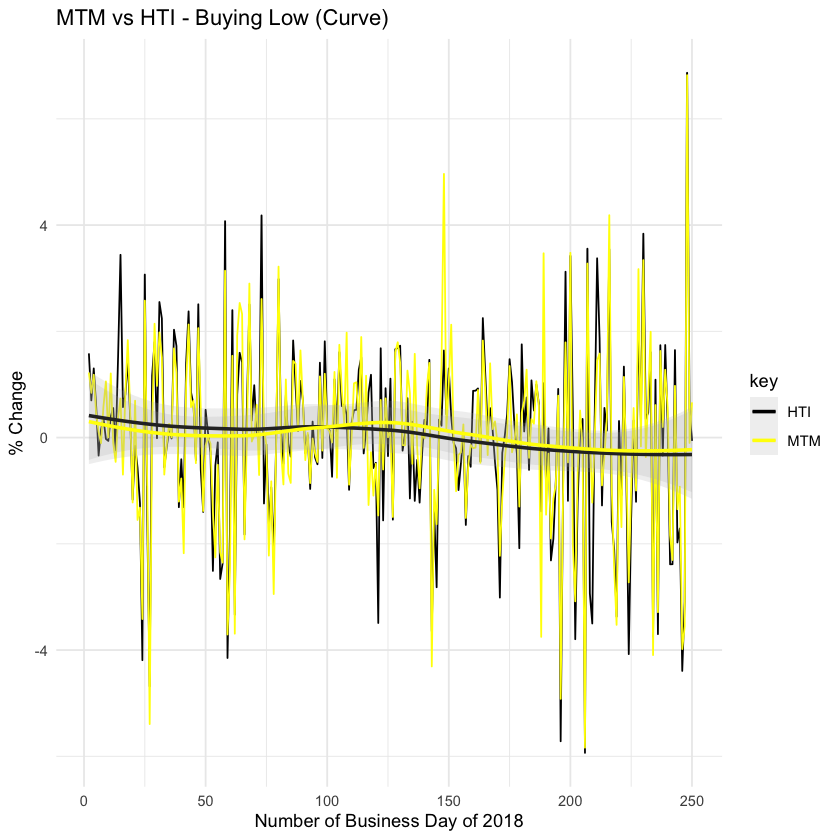

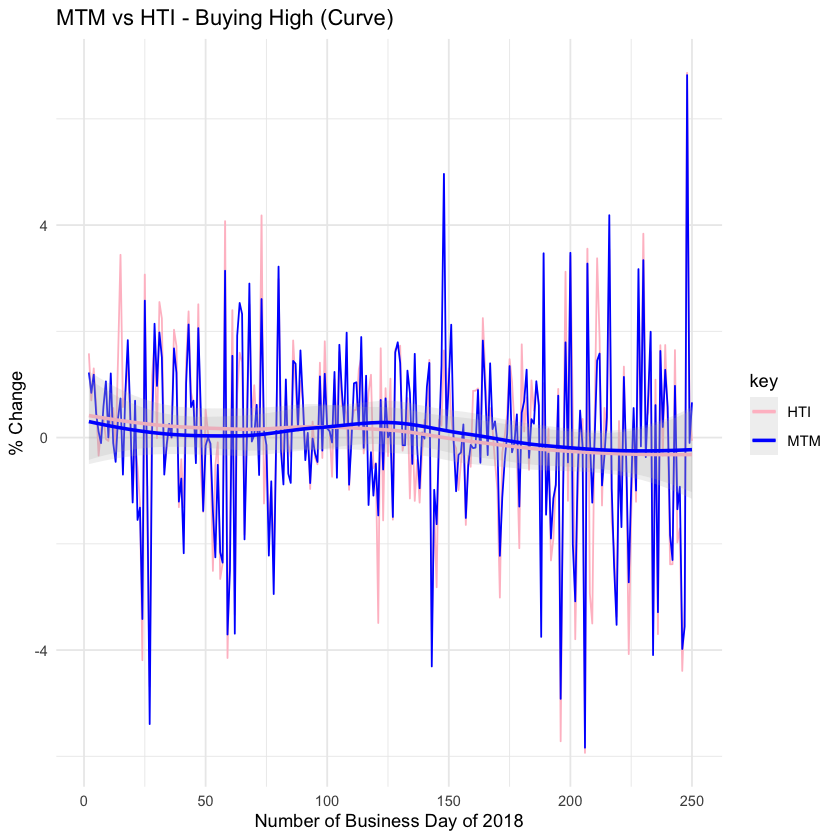

In [10]:
highTechIndex = rowMeans(universe[, c('ibm_close', 'msft_close', 'goog_close', 'aapl_close', 'amzn_close',
                                        'fb_close', 'nflx_close', 'tsla_close', 'orcl_close', 'sap_close')])

# Buying Low HTI
mtmChangeLow = c(NA, diff(mtmSeries) / head(mtmSeries, -1) * 100)
htiChangeLow = c(NA, diff(highTechIndex) / head(highTechIndex, -1) * 100)

# Create a data frame for ggplot for Buying Low
metricsDataFrameLow = data.frame(DayCount = 1:length(mtmChangeLow), 
                                  MTM = mtmChangeLow,
                                  HTI = htiChangeLow)

metricsDataFrameLow %>%
    gather(key, value, MTM, HTI) %>%
    ggplot(aes(x = DayCount, y = value, colour = key)) +
    geom_line(size = 0.5) +  # Line for MTM and HTI
    geom_smooth(aes(fill = key), size = 1, alpha = 0.2, se = TRUE) +
    scale_colour_manual(values = c("black", "yellow")) +
    scale_fill_manual(values = c("grey70", "grey70")) +
    labs(title = "MTM vs HTI - Buying Low (Curve)", 
         y = "% Change", 
         x = "Number of Business Day of 2018") +
    theme_minimal()

# Buying High HTI
mtmChangeHigh = c(NA, diff(mtmSeries) / head(mtmSeries, -1) * 100)
htiChangeHigh = c(NA, diff(highTechIndex) / head(highTechIndex, -1) * 100)

# Create a data frame for ggplot for Buying High
metricsDataFrameHigh = data.frame(DayCount = 1:length(mtmChangeHigh), 
                                   MTM = mtmChangeHigh,
                                   HTI = htiChangeHigh)

metricsDataFrameHigh %>%
    gather(key, value, MTM, HTI) %>%
    ggplot(aes(x = DayCount, y = value, colour = key)) +
    geom_line(size = 0.5) +  # Line for MTM and HTI
    geom_smooth(aes(fill = key), size = 1, alpha = 0.2, se = TRUE) +
    scale_colour_manual(values = c("pink", "blue")) +
    scale_fill_manual(values = c("grey70", "grey70")) +
    labs(title = "MTM vs HTI - Buying High (Curve)", 
         y = "% Change", 
         x = "Number of Business Day of 2018") +
    theme_minimal()



<h1>USD/JPY 2018</h1>

In [11]:
# Load the USD/JPY data
usd_JPY = read.csv("usdjpy.csv")

# Remove invalid characters. This was casuing issue with the file. It somehow had speical character like ˇ. 
colnames(usd_JPY) = gsub("ˇ", "", colnames(usd_JPY))  

head(usd_JPY)


,Date,Open,High,Low,Close,Adj.Close,Volume
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,31-Dec-18,110.324,110.468,109.659,110.330,110.330,-
2,28-Dec-18,110.860,110.930,110.222,110.855,110.855,-
3,27-Dec-18,111.221,111.222,110.653,111.206,111.206,-
4,26-Dec-18,110.431,110.698,110.286,110.402,110.402,-
5,25-Dec-18,110.314,110.344,109.991,110.311,110.311,-
6,24-Dec-18,111.100,111.140,110.267,111.054,111.054,-


In [12]:
# Convert the 'Date' column to Date format or else we get error
usd_JPY$Date = as.Date(usd_JPY$Date, format = "%d-%b-%y")

# Get the Close prices
closeRates = usd_JPY$Close

head(closeRates)

[1] 110.330 110.855 111.206 110.402 110.311 111.054

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_smooth()`).”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_line()`).”


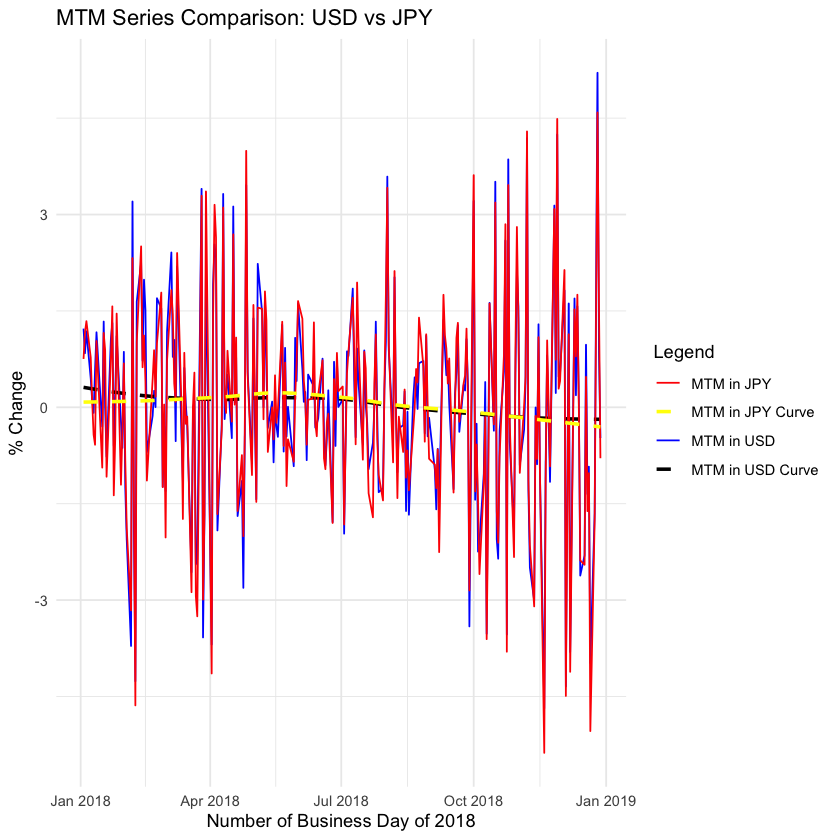

In [15]:
# Get the 'Close' prices for USD/JPY
closeRates = usd_JPY$Close

# Create a dataframe with the date and close rates for USD/JPY
usd_jpy_df = data.frame(Date = usd_JPY$Date, Close = closeRates)

# Merge the universe and usd_jpy_df by Date to align the data
merged_data = merge(universe, usd_jpy_df, by = "Date")

# Convert MTM series from USD to JPY
merged_data$MTM_JPY = mtmSeries * merged_data$Close

# Calculate percentage changes
merged_data$MTM_Percent_Change = c(NA, diff(merged_data$MTM_JPY) / head(merged_data$MTM_JPY, -1) * 100)
merged_data$MTM_USD_Percent_Change = c(NA, diff(mtmSeries) / head(mtmSeries, -1) * 100)

# Plotting the smooth curves for the MTM Series Comparison
ggplot(merged_data, aes(x = Date)) +
  geom_line(aes(y = MTM_USD_Percent_Change, color = "MTM in USD"), size = 0.5) +
  geom_smooth(aes(y = MTM_USD_Percent_Change, color = "MTM in USD Curve"), method = "loess", se = FALSE, linetype = "dashed", size = 1) + 
  geom_line(aes(y = MTM_Percent_Change, color = "MTM in JPY"), size = 0.5) +
  geom_smooth(aes(y = MTM_Percent_Change, color = "MTM in JPY Curve"), method = "loess", se = FALSE, linetype = "dashed", size = 1) + 
  labs(title = "MTM Series Comparison: USD vs JPY",
       x = "Number of Business Day of 2018",
       y = "% Change",
       color = "Legend") +
  theme_minimal() +
  scale_color_manual(values = c("MTM in USD" = "blue", "MTM in USD Curve" = "black", 
                                 "MTM in JPY" = "red", "MTM in JPY Curve" = "yellow"))


<h1>Optimal days Interval that Maximizes the MTM </h1>

In [16]:

day_intervals = 1:30
mtm_values_low = numeric(length(day_intervals))
mtm_values_high = numeric(length(day_intervals))

for (dayInterval in day_intervals) {
  
  initializePortfolio()
  
  for (currentDay in 2:nrow(universe)) {
    rebalance(currentDay, lowStrategy = TRUE, dayInterval = dayInterval)
  }

  mtm_values_low[dayInterval] = mtmSeries[length(mtmSeries)]
  
  initializePortfolio()
  
  for (currentDay in 2:nrow(universe)) {
    rebalance(currentDay, lowStrategy = FALSE, dayInterval = dayInterval)
  }
  
  mtm_values_high[dayInterval] = mtmSeries[length(mtmSeries)]
}

optimal_interval_low = day_intervals[which.max(mtm_values_low)]
optimal_mtm_value_low = max(mtm_values_low)

optimal_interval_high = day_intervals[which.max(mtm_values_high)]
optimal_mtm_value_high = max(mtm_values_high)

cat("\n")
cat("Optimal Rebalancing Interval (Low Strategy):", optimal_interval_low, "days\n")
cat("Maximum MTM Value on 12/31/2018 (Low Strategy):", optimal_mtm_value_low, "\n")
cat("Optimal Rebalancing Interval (High Strategy):", optimal_interval_high, "days\n")
cat("Maximum MTM Value on 12/31/2018 (High Strategy):", optimal_mtm_value_high, "\n")



Total ibm shares:  6781
Total msft shares:  11634
Total goog shares:  18779
Total aapl shares:  23223
Total amzn shares:  16820
Total Remaining Cash: 150.5
Total ibm shares:  6781
Total msft shares:  11634
Total goog shares:  18779
Total aapl shares:  23223
Total amzn shares:  16820
Total Remaining Cash: 150.5
Total ibm shares:  6781
Total msft shares:  11634
Total goog shares:  18779
Total aapl shares:  23223
Total amzn shares:  16820
Total Remaining Cash: 150.5
Total ibm shares:  6781
Total msft shares:  11634
Total goog shares:  18779
Total aapl shares:  23223
Total amzn shares:  16820
Total Remaining Cash: 150.5
Total ibm shares:  6781
Total msft shares:  11634
Total goog shares:  18779
Total aapl shares:  23223
Total amzn shares:  16820
Total Remaining Cash: 150.5
Total ibm shares:  6781
Total msft shares:  11634
Total goog shares:  18779
Total aapl shares:  23223
Total amzn shares:  16820
Total Remaining Cash: 150.5
Total ibm shares:  6781
Total msft shares:  11634
Total goog sh